In [2]:
# The '%' sign ensures installation in the current notebook kernel
%pip install numpy pandas matplotlib seaborn scipy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 116.4 kB/s eta 0:00:00 kB/s eta 0:00:01:01
  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scipy-1.17.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp312-cp312-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 1.4 MB/s eta 0:00:00m eta 0:00:010:00:01m
Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

5-Number Summary:
 min   -1.918771
25%   -0.805661
50%    0.084107
75%    0.538170
max    2.720169
dtype: float64

Shapiro-Wilk Test: Statistics=0.978, p-value=0.085
Conclusion: Data looks Gaussian (Fail to reject H0)


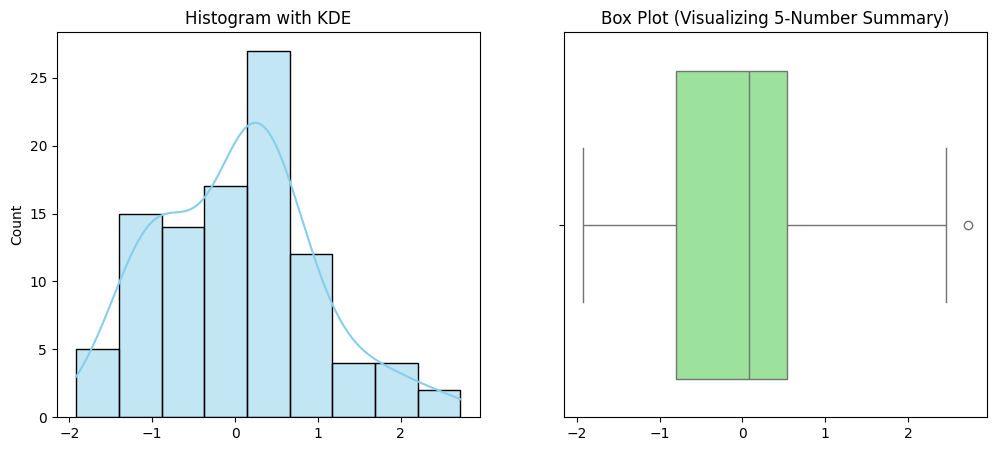

In [6]:

# 1. Create or Load Data
# mean as 0 using loc=0, standard deviation as 1 using scale=1 in below line of code
#loc=0 (Mean): This ensures the "peak" of your bell curve is centered exactly at zero.
#scale=1 (Standard Deviation): This defines the "spread." In a normal distribution, about 68% of your data points will fall between and 
#(one standard deviation from the mean).
#size=100: This is your sample size.
data = np.random.normal(loc=0, scale=1, size=100) # Generating normal data

# 2. 5-Number Summary
# pd.Series(data): Converts the raw list of numbers into a Pandas Series so we can use built-in functions.
#.describe(): Calculates several statistics (count, mean, std, etc.).
#[['min', '25%', '50%', '75%', 'max']]: This filters the results to only show the 5-number summary 
#(Minimum, 1st Quartile, Median, 3rd Quartile, and Maximum).

summary = pd.Series(data).describe()[['min', '25%', '50%', '75%', 'max']]
print("5-Number Summary:\n", summary)

# 3. Normality Test (Shapiro-Wilk)
# Null Hypothesis: The data is normally distributed
# This is a mathematical test for normality. It returns two values:
#stat: The test statistic (how close the data fits a normal curve).
#p: The p-value. If this value is greater than 0.05, you can generally assume your data is normally distributed. 
#If it's less, the data is likely skewed or "non-normal."

stat, p = stats.shapiro(data)
print(f"\nShapiro-Wilk Test: Statistics={stat:.3f}, p-value={p:.3f}")
if p > 0.05:
    print("Conclusion: Data looks Gaussian (Fail to reject H0)")
else:
    print("Conclusion: Data does not look Gaussian (Reject H0)")

# 4. Plotting (Histogram + Box Plot for 5-number summary)
plt.figure(figsize=(12, 5)) # # Sets the width and height of the entire window

plt.subplot(1, 2, 1) # # Tells Python to create a grid of 1 row, 2 columns, and use slot #1
sns.histplot(data, kde=True, color='skyblue') # kde=True adds the "smooth" curve line over the bars
plt.title('Histogram with KDE')

plt.subplot(1, 2, 2)  # Use the second slot in our grid
# You are right: you only passed the raw data to the function(x=data). The reason it works is that Seaborn (and the underlying Matplotlib engine) 
# is designed to do the math for you automatically.
# How it works behind the scenes
#When you call sns.boxplot(x=data), the function takes that list of numbers and performs its own internal calculations before drawing 
#anything. It follows these steps:
#Sorts the data from lowest to highest.
#Calculates the Median (50th percentile): It finds the middle value and draws the line inside the box.
#Calculates the Quartiles (25th and 75th percentiles): It finds these points to draw the edges of the box.
#Calculates the Whiskers: It looks for the Minimum and Maximum values (excluding outliers) and draws the lines extending from the box.
sns.boxplot(x=data, color='lightgreen')    # This visually represents your 5-number summary
plt.title('Box Plot (Visualizing 5-Number Summary)')

plt.show()


Explaination of below code
Line-by-Line Explanation
1. Data Generation
data = np.random.normal(50, 10, 1000): We create a dataset where the average is 50. Since we use the normal function, we expect the resulting plot to be symmetrical.
2. Mathematical Summary
pd.Series(data): We wrap the data in a Pandas Series to use the .describe() method.
summary[['min', '25%', '50%', '75%', 'max']]: We extract exactly five numbers:
Min: The smallest value.
25% (Q1): The point where 25% of the data lies below it.
50% (Median): The exact middle of the data.
75% (Q3): The point where 75% of the data lies below it.
Max: The largest value.
3. Visual Verification (sns.boxplot)
showmeans=True: This adds a small triangle/dot to represent the Mean. In a normal distribution, the Mean and Median should be almost identical.
========================================================================================================
How to Verify Normality (Comparing Math to Plot)
To "verify" normality using the output above, look for these three things:
The Median Test (The Center):
Math: Look at the 50% value.
Plot: Look at the line inside the box.
Normality Check: Is the line in the center of the box? If yes, it’s symmetrical.
The Whisker Test (The Spread):
Math: Calculate (Median - Min) and (Max - Median).
Plot: Look at the left and right whiskers.
Normality Check: Are the distances roughly equal? In normal data, the tails (whiskers) should be about the same length.
The Interquartile Range (The Box):
Math: Calculate (Q3 - Median) and (Median - Q1).
Plot: Look at the two halves of the colored box.
Normality Check: Are the two halves of the box equal in size?
Summary Table for your comparison:
Statistical Number	Box Plot Part	Normal Distribution Signal
Min	Left Whisker Tip	Distance from Median is similar to Max.
25% (Q1)	Left Edge of Box	Distance to Median is same as Q3 to Median.
50% (Median)	The Middle Line	Must be in the center of the box.
75% (Q3)	Right Edge of Box	Distance to Median is same as Q1 to Median.
Max	Right Whisker Tip	No extreme isolated dots (outliers) on one side.


--- Mathematical 5-Number Summary ---
min    19.804878
25%    43.520004
50%    49.997492
75%    56.609153
max    89.262377
dtype: float64


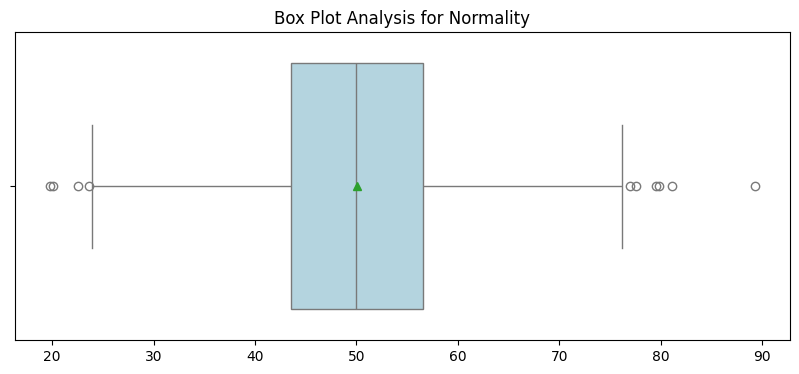

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate 1000 points of Normal Data
data = np.random.normal(loc=50, scale=10, size=1000)

# 2. Calculate Mathematical 5-Number Summary
df_series = pd.Series(data)
summary = df_series.describe(percentiles=[.25, .5, .75])
five_num = summary[['min', '25%', '50%', '75%', 'max']]

print("--- Mathematical 5-Number Summary ---")
print(five_num)

# 3. Create the Visualization
plt.figure(figsize=(10, 4))
sns.boxplot(x=data, color='lightblue', showmeans=True) 
plt.title('Box Plot Analysis for Normality')
plt.show()



__Python Code for Parallel Comparison__

--- NORMAL DATA SUMMARY ---
min    17.587327
25%    43.524097
50%    50.253006
75%    56.479439
max    88.527315
dtype: float64

--- NON-NORMAL DATA SUMMARY ---
min     0.032235
25%     2.839545
50%     7.259312
75%    13.716843
max    74.417229
dtype: float64


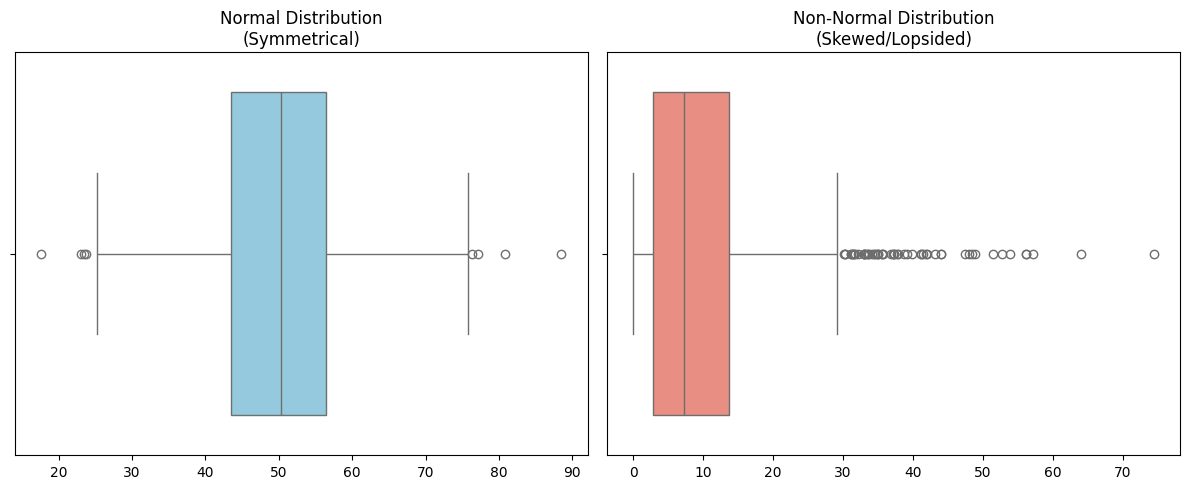

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate Data
np.random.seed(42) # This ensures you get the same random numbers every time
normal_data = np.random.normal(loc=50, scale=10, size=1000)
non_normal_data = np.random.exponential(scale=10, size=1000)

# 2. Create Mathematical 5-Number Summaries
def get_summary(data):
    s = pd.Series(data).describe()
    return s[['min', '25%', '50%', '75%', 'max']]

norm_sum = get_summary(normal_data)
non_norm_sum = get_summary(non_normal_data)

# Print Math Results
print("--- NORMAL DATA SUMMARY ---")
print(norm_sum)
print("\n--- NON-NORMAL DATA SUMMARY ---")
print(non_norm_sum)

# 3. Create Parallel Box Plots
plt.figure(figsize=(12, 5))

# Plot 1: Normal
plt.subplot(1, 2, 1)
sns.boxplot(x=normal_data, color='skyblue')
plt.title('Normal Distribution\n(Symmetrical)')

# Plot 2: Non-Normal
plt.subplot(1, 2, 2)
sns.boxplot(x=non_normal_data, color='salmon')
plt.title('Non-Normal Distribution\n(Skewed/Lopsided)')

plt.tight_layout()
plt.show()
